# Hotel Cancellations Prediction Using Random Forest Classification

ABC Hotel is a resort hotel in Lisbon, Portugal. The hotel management aims to optimize its revenue management by introducing a cancellation fee for hotel room bookings. To achieve this, the hotel needs to predict the expected revenue from bookings that are likely to be cancelled. This involves developing a data-driven model that accurately forecasts cancellation rates and calculates potential revenue from these cancellations. By analyzing historical booking data, customer profiles, and booking patterns, the model should provide actionable insights to help Resort Hotel implement a strategic cancellation fee policy that maximizes revenue without adversely affecting customer satisfaction.

The primary objectives of this project are:

Cancellation Rate Prediction: Develop a predictive model to estimate the probability of booking cancellations based on various factors such as booking lead time, customer demographics, seasonality, and booking source.

Revenue Calculation from Cancellations: Calculate the expected revenue from cancellation fees by applying the predicted cancellation rates to the total number of bookings and proposed fee structures.

Policy Optimization: Provide recommendations on the optimal cancellation fee structure that balances maximizing revenue and maintaining competitive advantage and customer loyalty.

Key questions to address include:

- What are the main factors influencing booking cancellations at ABC Hotel?
- How can we accurately predict the likelihood of a booking being canceled?
- What is the potential revenue impact of different cancellation fee scenarios?
- How can ABC Hotel implement a fair yet profitable cancellation fee policy?

Deliverables for this project will include a predictive model, a revenue impact analysis, and a set of actionable recommendations for the cancellation fee policy. This will empower ABC Hotel to make data-driven decisions to enhance its revenue management strategy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from datetime import timedelta
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn import metrics


pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.max_columns',None)

raw_df = pd.read_csv(r"E:\Upgrad Datasets\LJMU material\Datasets\Hotel Bookings\hotel_bookings.csv")

# arrival date column has to be created by combining arrival month date and year

df = raw_df.copy()

df.head()

def months_num(x):
    m = {'October':10,
         'September':9,
         'July':7,
         'August':8,
         'May':5,
         'April':4,
         'June':6,
         'November':11,
         'March':3,
         'December':12,
         'February':2,
         'January':1}
    return m.values()

df['arrival_date_year'] = df['arrival_date_year'].astype('str')

df[['arrival_date_year','arrival_date_day_of_month']] = df[['arrival_date_year','arrival_date_day_of_month']].astype('str')

df['arrival_date'] = df['arrival_date_year']+"-"+df['arrival_date_month'] + "-" + df['arrival_date_day_of_month'].astype('str')
df['arrival_date'] = pd.to_datetime(df['arrival_date'])

df.drop(['arrival_date_year','arrival_date_month','arrival_date_day_of_month'],axis=1,inplace=True)

df.head()

,hotel,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
0,Resort Hotel,1,338,41,2,0,55,0.00,0,HB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.00,0,0,Canceled,02-01-2015,2015-10-04
1,Resort Hotel,1,336,37,1,2,50,0.00,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.00,0,0,Canceled,18-01-2015,2015-09-07
2,Resort Hotel,1,304,36,0,3,40,0.00,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.00,0,0,Canceled,02-01-2015,2015-09-03
3,Resort Hotel,1,349,39,1,3,27,0.00,0,HB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.00,0,0,Canceled,02-01-2015,2015-09-21
4,Resort Hotel,1,352,39,1,3,27,0.00,0,HB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Group,0.00,0,0,Canceled,02-01-2015,2015-09-24


In [2]:
print("Earliest Arrival date:",np.min(df.arrival_date))

print("Checking Null values and datatypes")
df.info()

Earliest Arrival date: 2015-07-01 00:00:00
Checking Null values and datatypes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_week_number        119390 non-null  int64         
 4   stays_in_weekend_nights         119390 non-null  int64         
 5   stays_in_week_nights            119390 non-null  int64         
 6   adults                          119390 non-null  int64         
 7   children                        119386 non-null  float64       
 8   babies                          119390 non-null  int64         
 9   meal                            119390 non-null

In [3]:
# hotel, meal, country,market_segment, distribution_channel, reserved_room_type, assigned_room_type, deposit_type,
# customer_type, reservation_status,reservation_status_date are all object type

df.hotel.value_counts()

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

In [4]:
df.country.value_counts()
# PRT stands for Portugal, which refers to domestic consumers. 
# We can make this a binary columns with domestic and international consumers

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
       ...  
MLI        1
NAM        1
BDI        1
NIC        1
KIR        1
Name: count, Length: 177, dtype: int64

In [5]:
df.market_segment.value_counts()
# Unclear what is market_segments. We can club Corporate, complementary, Aviation and undefined as Others

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [6]:
df.distribution_channel.value_counts()
# Highly unbalanced

df.reserved_room_type.value_counts()

reserved_room_type
A    85994
D    19201
E     6535
F     2897
G     2094
B     1118
C      932
H      601
P       12
L        6
Name: count, dtype: int64

In [7]:
df.assigned_room_type.value_counts()

assigned_room_type
A    74053
D    25322
E     7806
F     3751
G     2553
C     2375
B     2163
H      712
I      363
K      279
P       12
L        1
Name: count, dtype: int64

In [8]:
df.deposit_type.value_counts()
# Imbalanced, remove column

deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

In [9]:
df.customer_type.value_counts()
# Remove group as they are outliers

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

In [10]:
df.reservation_status.value_counts()
# Assume all as checked out

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

In [11]:
df.reservation_status_date.value_counts()
# seems irrelevant

reservation_status_date
21-10-2015    1461
06-07-2015     805
25-11-2016     790
01-01-2015     763
18-01-2016     625
              ... 
07-04-2015       1
12-02-2015       1
27-02-2015       1
26-02-2015       1
18-11-2014       1
Name: count, Length: 926, dtype: int64

In [12]:
df.describe()
## ignoring is_cancelled for now as we may assume all bookings were confirmed and used by customer

,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,arrival_date
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.00,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00,119390
mean,0.37,104.01,27.17,0.93,2.50,1.86,0.10,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57,2016-08-28 16:39:45.727447808
min,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00,2015-07-01 00:00:00
25%,0.00,18.00,16.00,0.00,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00,2016-03-13 00:00:00
50%,0.00,69.00,28.00,1.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00,2016-09-06 00:00:00
75%,1.00,160.00,38.00,2.00,3.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00,2017-03-18 00:00:00
max,1.00,737.00,53.00,19.00,50.00,55.00,10.00,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00,2017-08-31 00:00:00
std,0.48,106.86,13.61,1.00,1.91,0.58,0.40,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79,NaN


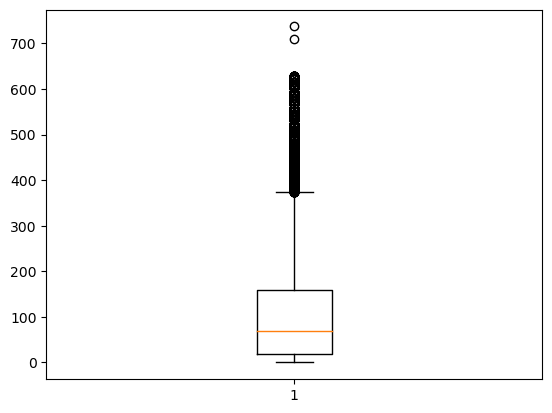

In [13]:
# checking dispersion of lead_time
plt.boxplot(df.lead_time)
plt.show()

In [14]:
# checking rows where lead time is greater than 365
df[df.lead_time>365]

,hotel,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
347,Resort Hotel,0,542,40,2,5,3,0.00,0,HB,GBR,Groups,TA/TO,0,0,0,A,C,1,No Deposit,253.00,NaN,0,Transient-Party,99.00,0,0,Check-Out,03-10-2016,2016-09-26
350,Resort Hotel,0,383,41,0,3,3,0.00,0,BB,GBR,Groups,TA/TO,0,0,0,A,C,1,No Deposit,315.00,NaN,0,Transient-Party,66.00,0,0,Check-Out,09-10-2016,2016-10-06
359,Resort Hotel,0,385,43,1,4,3,0.00,0,BB,GBR,Groups,Corporate,0,0,0,A,C,1,No Deposit,NaN,NaN,0,Transient-Party,79.00,0,0,Check-Out,24-10-2016,2016-10-19
1131,Resort Hotel,0,386,43,1,3,3,0.00,0,BB,GBR,Groups,Corporate,0,0,0,A,A,1,No Deposit,NaN,NaN,0,Transient-Party,79.00,0,1,Check-Out,24-10-2016,2016-10-20
1132,Resort Hotel,0,386,43,1,3,3,0.00,0,BB,GBR,Groups,Corporate,0,0,0,A,A,3,No Deposit,NaN,NaN,0,Transient-Party,79.00,0,1,Check-Out,24-10-2016,2016-10-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118855,City Hotel,0,457,34,0,2,1,0.00,0,HB,DEU,Offline TA/TO,TA/TO,0,0,0,A,A,2,No Deposit,6.00,NaN,0,Transient-Party,95.50,0,1,Check-Out,27-08-2017,2017-08-25
118858,City Hotel,0,457,34,0,2,1,0.00,0,HB,DEU,Offline TA/TO,TA/TO,0,0,0,A,A,2,No Deposit,6.00,NaN,0,Transient-Party,95.50,0,1,Check-Out,27-08-2017,2017-08-25
118877,City Hotel,0,518,34,2,1,1,0.00,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,229.00,NaN,0,Transient-Party,0.00,0,0,Check-Out,29-08-2017,2017-08-26
119104,City Hotel,1,381,52,1,2,0,2.00,0,BB,DEU,Online TA,TA/TO,0,0,0,B,B,0,No Deposit,9.00,NaN,0,Transient,69.50,0,1,Canceled,23-12-2015,2016-12-23


In [15]:
# removing data points where lead_time is greater than 365 days
df = df[df['lead_time']<=365].copy()

In [16]:
# checking nulls
df.isna().sum()

df.drop(['agent','company'],axis=1,inplace=True)
df = df[~df.children.isna()]
df = df[~df.country.isna()].copy()

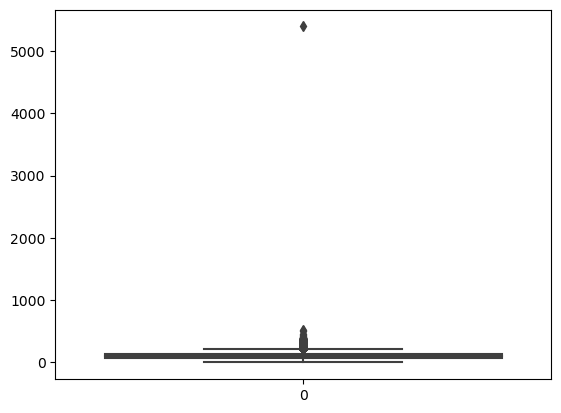

In [17]:
# checking dispersion of adr
sns.boxplot(df.adr)
plt.show()

In [18]:
print("Max adr:",np.max(df.adr))

Max adr: 5400.0


In [19]:
df = df[df.adr < np.max(df.adr)].copy()

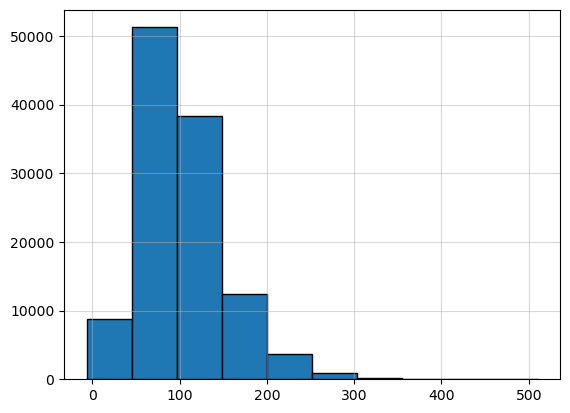

In [20]:
# sns.boxplot(df.adr)
plt.hist(df.adr,bins=10,edgecolor='black')
plt.grid(alpha=0.5)
plt.show()

In [21]:
print('Bookings where adr is greater than 300:', len(df[df.adr > 300]))

Bookings where adr is greater than 300: 273


In [22]:
df = df[df.adr <= 300].copy()

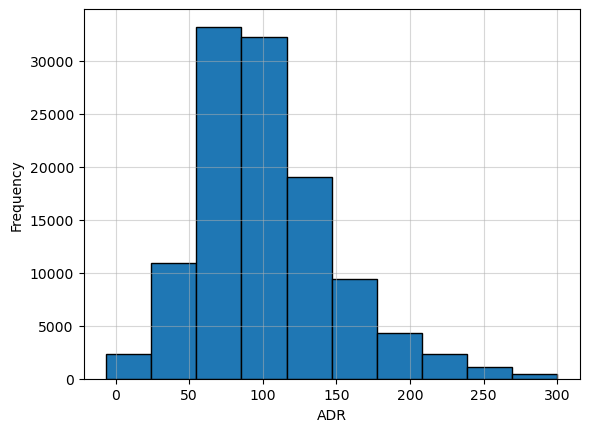

In [23]:
plt.hist(df.adr,bins=10,edgecolor='black')
plt.xlabel('ADR')
plt.ylabel('Frequency')
plt.grid(alpha=0.5)
plt.show()

In [24]:
# considering bookings where ADR is greater than 0
df = df[df['adr']>=0].copy()

# checking nulls 
df.isna().sum()

print("1st recorded date:",np.min(df['arrival_date'].dt.date))
print("last recorded date:",np.max(df['arrival_date'].dt.date))

print("Number of days between first and last recorded date:",(np.max(df['arrival_date'])-np.min(df['arrival_date'])).days)

# We have 792 days worth of data

df.rename(columns={'adults':'sum_guests'},inplace=True)

df.groupby('arrival_date')['sum_guests'].sum().reset_index()

1st recorded date: 2015-07-01
last recorded date: 2017-08-31
Number of days between first and last recorded date: 792


,arrival_date,sum_guests
0,2015-07-01,216
1,2015-07-02,186
2,2015-07-03,110
3,2015-07-04,171
4,2015-07-05,103
...,...,...
788,2017-08-27,332
789,2017-08-28,351
790,2017-08-29,205
791,2017-08-30,174


C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


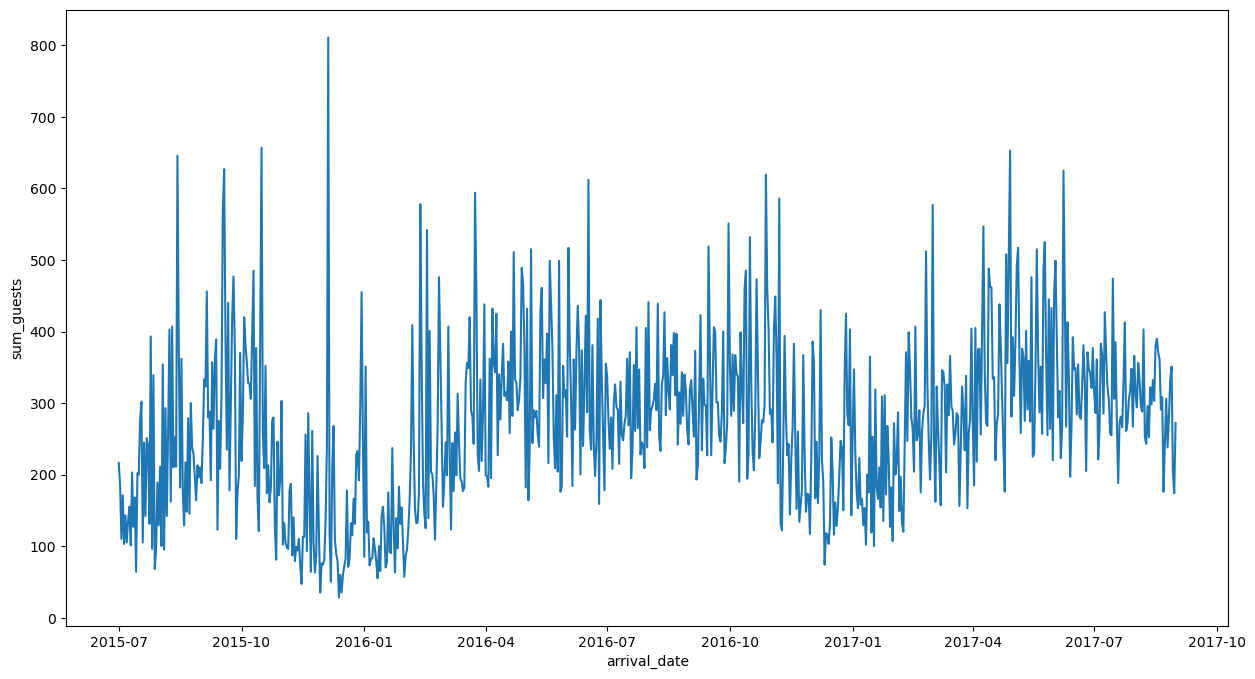

In [25]:
viz = df.groupby('arrival_date')['sum_guests'].sum().reset_index()

plt.figure(figsize=(15,8))
sns.lineplot(data=viz,x='arrival_date',y='sum_guests')
plt.show()

In [26]:
df['booking_date'] = df['arrival_date'] - pd.to_timedelta(df['lead_time'], unit='D')

In [27]:
# country to binary
df['country'] = df.country.apply(lambda x: 'domestic' if x == 'PRT' else 'international')

In [28]:
# meal
df['meal'] = df['meal'].apply(lambda x: 'BB' if x == 'BB' else 'Other Meal')

In [29]:
# market_segments
df['market_segment'] = df['market_segment'].apply(lambda x: 'Others'\
                                                  if x in ['Direct','Corporate','Complementary','Aviation'] else x)

# df.distribution_channel.value_counts()
df.drop('distribution_channel',axis=1,inplace=True)

# df.reserved_room_type.value_counts(normalize=True)
df.reserved_room_type = df.reserved_room_type.apply(lambda x: 'NotRoomTypeA' if x != 'A' else 'RoomTypeA')

print(df[(df.lead_time > 30)&(df.lead_time < 61)&(df.arrival_date=='2015-07-01')&(df.hotel=='Resort Hotel')].shape)
print(df[(df.lead_time < 31)&(df.arrival_date=='2015-07-01')&(df.hotel=='Resort Hotel')].shape)
print(df[(df.lead_time > 90)&(df.arrival_date=='2015-07-01')&(df.hotel=='Resort Hotel')].shape)

# bucketing lead times
df['lead_time'] = pd.cut(x=df['lead_time'],bins=[-1,30,90,1000],labels=['lt_0-30','lt_31-90','lt_91+'])

# assuming assigned room type as room reallocation as per availablility therefore removing this
df.drop(['assigned_room_type','deposit_type','reservation_status_date','arrival_date_week_number',\
            'reservation_status','booking_date'],axis=1,inplace=True)

# bookings = b0 + b1*leadTime + b2*sum_guests + b3*

dummies = pd.get_dummies(df,drop_first=True)
df = dummies.copy()
df.rename(columns={'hotel_Resort Hotel':'hotel'},inplace=True)

df.hotel = df.hotel.apply(lambda x: 'Resort Hotel' if x == 1 else 'City Hotel')

# Dividing into Resort Hotel and City Hotel

(6, 28)
(12, 28)
(11, 28)


In [30]:
resorthotel = df[df.hotel == 'Resort Hotel'].copy()

# INTERPRETATION: 
# at Lead Time 28 3 guests came
# at Lead Time 27 5 guests came
# at Lead Time 26 2 guests came and so on

In [31]:
resorthotel['is_canceled'].value_counts(normalize=True)

is_canceled
0   0.72
1   0.28
Name: proportion, dtype: float64

In [32]:
resorthotel.describe()

,is_canceled,stays_in_weekend_nights,stays_in_week_nights,sum_guests,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,arrival_date
count,38920.00,38920.00,38920.00,38920.00,38920.00,38920.00,38920.00,38920.00,38920.00,38920.00,38920.00,38920.00,38920.00,38920.00,38920
mean,0.28,1.20,3.13,1.87,0.13,0.01,0.05,0.10,0.13,0.29,0.53,94.32,0.14,0.62,2016-08-14 08:05:05.611510784
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2015-07-01 00:00:00
25%,0.00,0.00,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,50.44,0.00,0.00,2016-02-13 00:00:00
50%,0.00,1.00,3.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,76.00,0.00,0.00,2016-08-16 00:00:00
75%,1.00,2.00,5.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,125.00,0.00,1.00,2017-03-05 00:00:00
max,1.00,16.00,40.00,55.00,10.00,2.00,1.00,26.00,30.00,17.00,185.00,300.00,8.00,5.00,2017-08-31 00:00:00
std,0.45,1.14,2.45,0.70,0.44,0.12,0.21,1.35,0.94,0.73,7.49,59.11,0.35,0.81,NaN


In [33]:
resorthotel[resorthotel.is_canceled==0].describe()

,is_canceled,stays_in_weekend_nights,stays_in_week_nights,sum_guests,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,arrival_date
count,28123.00,28123.00,28123.00,28123.00,28123.00,28123.00,28123.00,28123.00,28123.00,28123.00,28123.00,28123.00,28123.00,28123.00,28123
mean,0.00,1.14,3.01,1.84,0.10,0.02,0.06,0.01,0.17,0.34,0.70,90.15,0.19,0.67,2016-08-06 07:49:44.532233216
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2015-07-01 00:00:00
25%,0.00,0.00,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,48.50,0.00,0.00,2016-02-06 00:00:00
50%,0.00,1.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,73.00,0.00,0.00,2016-08-08 00:00:00
75%,0.00,2.00,5.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,118.05,0.00,1.00,2017-02-20 00:00:00
max,0.00,16.00,40.00,4.00,3.00,2.00,1.00,5.00,30.00,17.00,185.00,300.00,8.00,5.00,2017-08-31 00:00:00
std,0.00,1.14,2.43,0.46,0.39,0.13,0.24,0.10,1.07,0.77,8.61,56.91,0.40,0.83,NaN


In [34]:
c1 = resorthotel[resorthotel.is_canceled==0].describe()

# stays_in_weekend_nights, stays_in_week_nights, 

resorthotel[resorthotel.is_canceled==1].describe()

c2 = resorthotel[resorthotel.is_canceled==1].describe()

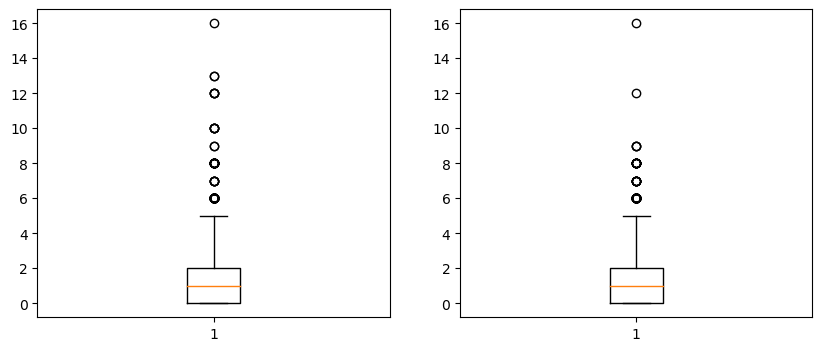

In [35]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.boxplot(resorthotel[resorthotel['is_canceled']==0]['stays_in_weekend_nights'])
plt.subplot(1,2,2)
plt.boxplot(resorthotel[resorthotel['is_canceled']==1]['stays_in_weekend_nights'])
plt.show()

In [36]:
resorthotel = resorthotel[resorthotel.stays_in_weekend_nights <= 5].copy()

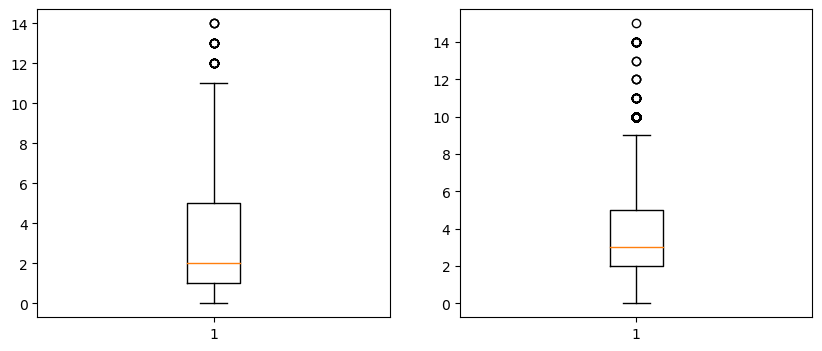

In [37]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.boxplot(resorthotel[resorthotel['is_canceled']==0]['stays_in_week_nights'])
plt.subplot(1,2,2)
plt.boxplot(resorthotel[resorthotel['is_canceled']==1]['stays_in_week_nights'])
plt.show()

In [38]:
resorthotel = resorthotel[resorthotel.stays_in_weekend_nights <= 11].copy()
resorthotel.describe()

,is_canceled,stays_in_weekend_nights,stays_in_week_nights,sum_guests,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,arrival_date
count,38742.00,38742.00,38742.00,38742.00,38742.00,38742.00,38742.00,38742.00,38742.00,38742.00,38742.00,38742.00,38742.00,38742.00,38742
mean,0.28,1.17,3.07,1.87,0.13,0.01,0.05,0.10,0.13,0.29,0.54,94.47,0.14,0.62,2016-08-14 04:54:38.302617344
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2015-07-01 00:00:00
25%,0.00,0.00,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,50.52,0.00,0.00,2016-02-13 00:00:00
50%,0.00,1.00,3.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,76.00,0.00,0.00,2016-08-15 00:00:00
75%,1.00,2.00,5.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,125.00,0.00,1.00,2017-03-05 00:00:00
max,1.00,5.00,15.00,55.00,10.00,2.00,1.00,26.00,30.00,16.00,185.00,300.00,8.00,5.00,2017-08-31 00:00:00
std,0.45,1.07,2.22,0.70,0.44,0.12,0.21,1.36,0.94,0.71,7.50,59.17,0.35,0.81,NaN


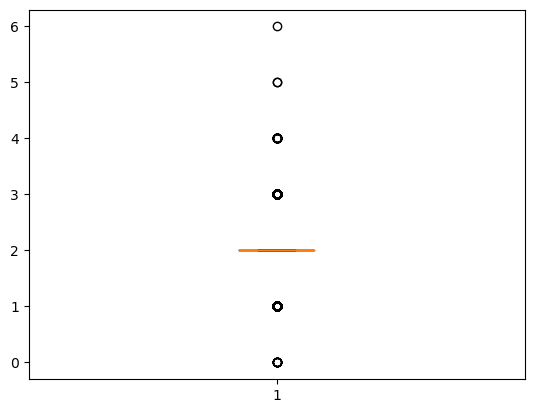

In [39]:
plt.boxplot(resorthotel[resorthotel['sum_guests'] < 10]['sum_guests'])
plt.show()

In [40]:
resorthotel.columns

Index(['is_canceled', 'stays_in_weekend_nights', 'stays_in_week_nights',
       'sum_guests', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'arrival_date', 'hotel', 'lead_time_lt_31-90', 'lead_time_lt_91+',
       'meal_Other Meal', 'country_international',
       'market_segment_Offline TA/TO', 'market_segment_Online TA',
       'market_segment_Others', 'reserved_room_type_RoomTypeA',
       'customer_type_Group', 'customer_type_Transient',
       'customer_type_Transient-Party'],
      dtype='object')

In [41]:
resorthotel.sum_guests.sort_values().tail(15)
resorthotel = resorthotel[resorthotel.sum_guests < 5].copy()
resorthotel = resorthotel[resorthotel['children'] < 3].copy()
resorthotel.drop(['children','babies'],axis=1,inplace=True)
resorthotel['total_of_special_requests'] = resorthotel['total_of_special_requests'].apply(lambda x: 'Greater Than 0 requests' if x > 0 else '0 requests')
resorthotel.drop(['is_repeated_guest','previous_cancellations','previous_bookings_not_canceled',\
                  'booking_changes','days_in_waiting_list','required_car_parking_spaces',\
                 'meal_Other Meal','reserved_room_type_RoomTypeA'],axis=1,inplace=True)

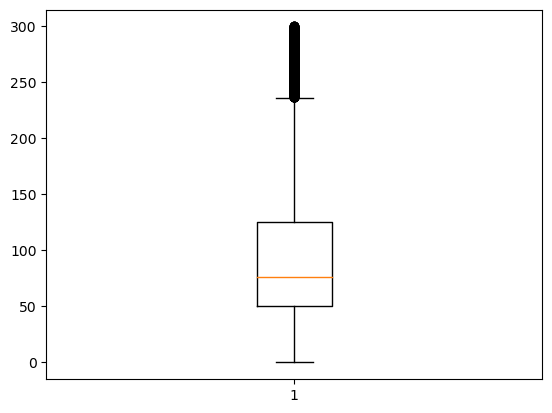

In [42]:
plt.boxplot(resorthotel.adr)
plt.show()

In [43]:
resorthotel[resorthotel.adr == 0]
resorthotel[resorthotel.adr != 0 ].sort_values(by='adr')
resorthotel = resorthotel[resorthotel.adr != 0 ].copy()
resorthotel.country_international.sum()
resorthotel.country_international.value_counts(normalize=True)
resorthotel['market_segment_Offline TA/TO'].value_counts(normalize=True)
resorthotel['market_segment_Online TA'].value_counts(normalize=True)
resorthotel['market_segment_Others'].value_counts(normalize=True)
# resorthotel['reserved_room_type_RoomTypeA'].value_counts(normalize=True)
resorthotel['customer_type_Group'].value_counts(normalize=True)
resorthotel.drop('customer_type_Group',axis=1,inplace=True)
resorthotel['customer_type_Transient'].value_counts(normalize=True)
resorthotel['customer_type_Transient-Party'].value_counts(normalize=True)
resorthotel['lead_time_lt_31-90'].value_counts(normalize=True)
resorthotel['lead_time_lt_91+'].value_counts(normalize=True)

lead_time_lt_91+
False   0.60
True    0.40
Name: proportion, dtype: float64

In [44]:
resorthotel['DoW'] = resorthotel['arrival_date'].dt.weekday

In [45]:
resorthotel['Month'] = resorthotel['arrival_date'].dt.month
resorthotel['DoW'].value_counts(normalize=True)
resorthotel['Month'].value_counts(normalize=True)

Month
8    0.12
7    0.12
4    0.09
5    0.09
10   0.08
3    0.08
6    0.08
2    0.08
9    0.08
12   0.06
11   0.06
1    0.05
Name: proportion, dtype: float64

In [46]:
# dummies_dow = pd.get_dummies(resorthotel['DoW'],drop_first=True)
# dummies_month = pd.get_dummies(resorthotel['Month'],drop_first=True)
# dummies_all = pd.concat([dummies_dow,dummies_month],axis=1)

# resorthotel = pd.concat([resorthotel,dummies_all],axis=1)

In [47]:
resorthotel['Day'] = resorthotel['arrival_date'].dt.dayofyear

In [48]:
resorthotel['Week'] = resorthotel['arrival_date'].dt.isocalendar().week

In [49]:
# resorthotel.drop(['arrival_date','DoW','Month'],axis=1,inplace=True)
resorthotel.drop(['arrival_date'],axis=1,inplace=True)

In [50]:
# day of week and month transformation

In [51]:
resorthotel['DoWSin'] = np.sin(resorthotel['DoW']*(2.*np.pi/7))
resorthotel['DoWCos'] = np.cos(resorthotel['DoW']*(2.*np.pi/7))
resorthotel['MonthSin'] = np.sin((resorthotel['Month']-1)*(2.*np.pi/12))
resorthotel['MonthCos'] = np.cos((resorthotel['Month']-1)*(2.*np.pi/12))
resorthotel['DaySin'] = np.sin(resorthotel['Day']*(2.*np.pi/31))
resorthotel['DayCos'] = np.cos(resorthotel['Day']*(2.*np.pi/31))
resorthotel['WeekSin'] = np.sin(resorthotel['Week']*(2.*np.pi/53))
resorthotel['WeekCos'] = np.cos(resorthotel['Week']*(2.*np.pi/53))

In [52]:
resorthotel.drop('hotel',axis=1,inplace=True)

dummies_spec = pd.get_dummies(resorthotel['total_of_special_requests'],drop_first=True)

resorthotel = pd.concat([resorthotel,dummies_spec],axis=1)
resorthotel.drop('total_of_special_requests',axis=1,inplace=True)

In [53]:
resorthotel.drop(['DoW','Month','Week','Day'],axis=1,inplace=True)

In [54]:
resorthotel.drop(['DoWSin','DayCos','MonthCos','MonthSin','sum_guests','DoWCos'],axis=1,inplace=True)

# Train-Test Split

In [55]:
resorthotel.reset_index(drop=True, inplace=True)

In [56]:
resorthotel

,is_canceled,stays_in_weekend_nights,stays_in_week_nights,adr,lead_time_lt_31-90,lead_time_lt_91+,country_international,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Others,customer_type_Transient,customer_type_Transient-Party,DaySin,WeekSin,WeekCos,Greater Than 0 requests
0,0,1,1,150.00,False,False,False,False,False,True,True,False,1.00,-0.29,-0.96,False
1,1,2,5,190.00,False,True,False,False,False,True,True,False,0.85,-0.70,-0.72,False
2,1,0,3,175.00,False,False,False,False,False,True,True,False,-1.00,0.61,-0.79,False
3,0,1,2,161.75,False,True,True,False,False,True,True,False,0.20,-0.90,-0.43,False
4,1,0,3,254.00,True,False,False,False,False,True,True,False,0.72,-0.90,-0.43,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37992,0,0,2,191.00,False,False,True,False,True,False,True,False,-0.85,-0.85,-0.53,True
37993,0,2,5,284.29,True,False,True,False,True,False,True,False,-0.97,-0.78,-0.63,True
37994,0,3,5,137.00,False,False,True,True,False,False,False,True,-1.00,-0.85,-0.53,True
37995,0,2,4,158.53,True,False,False,True,False,False,True,False,-0.85,-0.85,-0.53,False


In [57]:
x = resorthotel.drop('is_canceled',axis=1)
y = resorthotel['is_canceled']

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.7,random_state=10)

print(y_train.mean())
print(y_test.mean())

0.2816859044253111
0.27578947368421053


In [58]:
y_train

20362    0
35570    0
4458     1
5854     1
23528    0
        ..
10201    1
9372     1
28017    0
29199    0
17673    0
Name: is_canceled, Length: 26597, dtype: int64

In [59]:
x_test_summary = x_test.copy()

# # standardize
# scaler = StandardScaler()

# numeric_columns = x_train.columns

# # Scale selected columns in the DataFrame
# x_train[numeric_columns] = scaler.fit_transform(x_train[numeric_columns])

# from sklearn.linear_model import LogisticRegression

# logreg = LogisticRegression()
# # running RFE with 15 variables as output
# rfe = RFE(logreg)             
# rfe = rfe.fit(x_train, y_train)

# rfe

In [60]:
from sklearn.ensemble import RandomForestClassifier

In [61]:
rfc = RandomForestClassifier(n_estimators=100, max_depth=9, random_state=10, class_weight='balanced')
rfc.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=9, random_state=10)

In [62]:
y_train_pred = rfc.predict(x_train)

In [63]:
y_train_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [64]:
y_train_pred.mean()

0.34966349588299434

In [65]:
# Let's check the overall accuracy.
print('Accuracy :',metrics.accuracy_score(y_train_pred, y_train))

Accuracy : 0.833063879384893


In [66]:
y_test_pred = pd.Series(rfc.predict(x_test),name='is_canceled')

In [67]:
y_test_pred.mean()

0.34771929824561404

In [68]:
# Let's check the overall accuracy.
print('Accuracy :',metrics.accuracy_score(y_test_pred, y_test))

Accuracy : 0.8180701754385965


In [69]:
y_train_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [70]:
y_train_pred_final = pd.DataFrame({'Cancelled':y_train.values, 'Predicted':y_train_pred})
y_train_pred_final['Booking ID'] = y_train.index
y_train_pred_final.head()

,Cancelled,Predicted,Booking ID
0,0,0,20362
1,0,0,35570
2,1,0,4458
3,1,1,5854
4,0,0,23528


In [71]:
y_train_pred_final.query('Cancelled ==  1')

,Cancelled,Predicted,Booking ID
2,1,0,4458
3,1,1,5854
16,1,1,6981
18,1,1,4083
20,1,1,12097
...,...,...,...
26584,1,1,10742
26587,1,1,9289
26588,1,1,9224
26592,1,1,10201


In [72]:
feature_scores = pd.Series(rfc.feature_importances_, index=x_train.columns).sort_values(ascending=False)

feature_scores

country_international           0.25
lead_time_lt_91+                0.10
adr                             0.08
market_segment_Offline TA/TO    0.07
market_segment_Others           0.07
Greater Than 0 requests         0.06
customer_type_Transient         0.06
market_segment_Online TA        0.05
stays_in_week_nights            0.05
lead_time_lt_31-90              0.05
WeekCos                         0.04
WeekSin                         0.04
DaySin                          0.03
stays_in_weekend_nights         0.03
customer_type_Transient-Party   0.03
dtype: float64

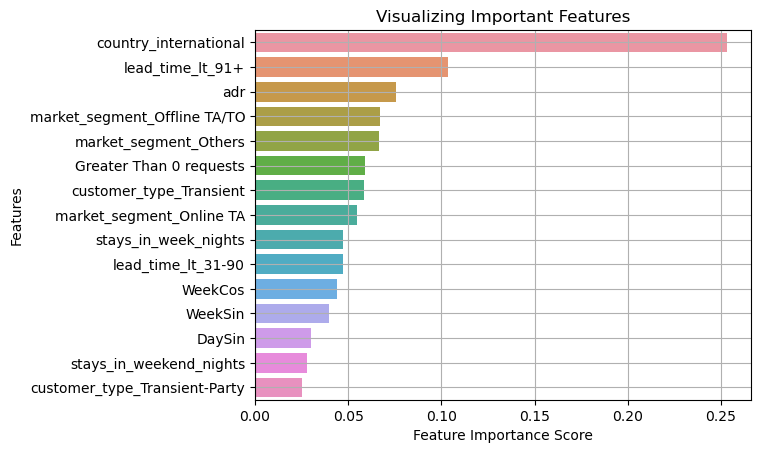

In [73]:
sns.barplot(x=feature_scores, y=feature_scores.index)


# Add labels to the graph

plt.xlabel('Feature Importance Score')

plt.ylabel('Features')



# Add title to the graph

plt.title("Visualizing Important Features")

plt.grid(0.4)

# Visualize the graph

plt.show()

In [74]:
# Confusion matrix 
confusion = metrics.confusion_matrix(y_train_pred_final.Cancelled, y_train_pred_final.Predicted )
print(confusion)

[[15981  3124]
 [ 1316  6176]]


In [75]:
# Let's check the overall accuracy.
print('Accuracy :',metrics.accuracy_score(y_train_pred_final.Cancelled, y_train_pred_final.Predicted))

Accuracy : 0.833063879384893


In [76]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

# Sensitivity of our logistic regression model
print("Sensitivity : ",TP / float(TP+FN))

# Let us calculate specificity
print("Specificity : ",TN / float(TN+FP))

# Calculate false postive rate - predicting converted lead when the lead actually was not converted
print("False Positive Rate :",FP/ float(TN+FP))

# positive predictive value 
print("Positive Predictive Value :",TP / float(TP+FP))

# Negative predictive value
print("Negative predictive value :",TN / float(TN+FN))

Sensitivity :  0.8243459690336359
Specificity :  0.8364825961790108
False Positive Rate : 0.16351740382098928
Positive Predictive Value : 0.6640860215053763
Negative predictive value : 0.9239174423310401


# Test set

In [77]:
y_test_pred

0        0
1        0
2        0
3        0
4        0
        ..
11395    1
11396    0
11397    1
11398    1
11399    0
Name: is_canceled, Length: 11400, dtype: int64

In [78]:
# Confusion matrix 
confusion = metrics.confusion_matrix(y_test, y_test_pred )
print(confusion)

[[6809 1447]
 [ 627 2517]]


# Let's check the overall accuracy.

In [79]:
print('Accuracy :',metrics.accuracy_score(y_train_pred_final.Cancelled, y_train_pred_final.Predicted))

Accuracy : 0.833063879384893


In [80]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

# Sensitivity of our logistic regression model
print("Sensitivity : ",TP / float(TP+FN))

# Let us calculate specificity
print("Specificity : ",TN / float(TN+FP))

# Calculate false postive rate - predicting converted lead when the lead actually was not converted
print("False Positive Rate :",FP/ float(TN+FP))

# positive predictive value 
print("Positive Predictive Value :",TP / float(TP+FP))

# Negative predictive value
print("Negative predictive value :",TN / float(TN+FN))

Sensitivity :  0.8005725190839694
Specificity :  0.8247335271317829
False Positive Rate : 0.17526647286821706
Positive Predictive Value : 0.6349646821392533
Negative predictive value : 0.915680473372781


In [81]:
# since we won't get a cancellation probability like we do in a Logistic Regression model,
# I will have to find another way to make a business use case

In [82]:
# I will use the sensitivity as a calculate the expected revenue from cancellations
# Sensitivity is used because we want to predict whether a customer will cancel and if he/she has actually cancelled

In [83]:
y_test_pred = pd.DataFrame({'Cancelled':y_test.values, 'Predicted':y_test_pred})
y_test_pred['Booking ID'] = y_test.index
y_test_pred.head()

,Cancelled,Predicted,Booking ID
0,0,0,21301
1,0,0,13638
2,0,0,12575
3,0,0,25174
4,0,0,20385


In [84]:
x_test['Booking ID'] = x_test.index

In [85]:
x_test_summary = x_test[['Booking ID','adr']].copy()

In [86]:
booking_id = raw_df[['lead_time']].copy()

In [87]:
booking_id.insert(0,'Booking ID',booking_id.index)

In [88]:
x_test_summary = pd.merge(x_test_summary,booking_id, on=['Booking ID'], how='left')

In [89]:
y_pred_final =  x_test_summary.copy()

In [90]:
y_pred_final

,Booking ID,adr,lead_time
0,21301,115.20,1
1,13638,148.16,364
2,12575,139.00,76
3,25174,54.00,9
4,20385,83.85,3
...,...,...,...
11395,29381,194.00,66
11396,35056,28.50,11
11397,13499,80.00,383
11398,10511,147.00,183


In [91]:
# objective: calculate cancellation rate
# calculate expected revenue from cancellations

# Euros 100 
# cancellation charge; 20%

print('Total cancellations:', y_test_pred.Predicted.sum())
print('Total booking ID:', y_test_pred.shape[0])
print('Cancellation rate:', round(100 * y_test_pred.Predicted.mean(),2))

Total cancellations: 3964
Total booking ID: 11400
Cancellation rate: 34.77


In [92]:
# adr = x_test_summary['adr'].to_frame()
# adr.reset_index(inplace=True)
# adr.rename(columns={'index':'CustID'},inplace=True)

In [93]:
# cancellation_final = y_pred_final.merge(adr,on='CustID',how='inner')

In [94]:
cancellation_final = x_test_summary.copy()

In [95]:
y_test_pred

,Cancelled,Predicted,Booking ID
0,0,0,21301
1,0,0,13638
2,0,0,12575
3,0,0,25174
4,0,0,20385
...,...,...,...
11395,0,1,29381
11396,0,0,35056
11397,1,1,13499
11398,1,1,10511


In [96]:
cancellation_final = pd.merge(cancellation_final,y_test_pred,on='Booking ID',how='left')

In [97]:
cancelled_bookings1 = cancellation_final[cancellation_final.Predicted == 1].copy()

In [98]:
print("Sensitivity : ",TP / float(TP+FN))

Sensitivity :  0.8005725190839694


In [99]:
cancelled_bookings1['Sensitivity'] = round(TP / float(TP+FN),2)

# Scenario 1: Charging 20% on all cancellations

In [100]:
# scenario when we charge 20% on all cancellations
cancelled_bookings1['ExpectedRev'] = (1 - cancelled_bookings1['Sensitivity']) * cancelled_bookings1['adr'] * 0.2

In [101]:
# Explanation:
# Suppose a customer is predicted to cancel, which means we are predicting 1
# Now since our Sensitivity is 80%, it means 8 out of 10 times we are correct while predicting class 1
# So if a hotel is booked at a price of 100 euros
# Cancelling the booking means the hotel has to return 100 euros
# With 80% sensitivity, our expected revenue from the cancellation is 20 euros [100 * (1 - 0.8)]
# In this scenario we are charging 20% of the cancellation, the final expected revenue iis 100 * (1 - 0.8) * 0.2

In [110]:
print('Expected Revenue from cancellations:',round(cancelled_bookings1.ExpectedRev.sum(),0))

Expected Revenue from cancellations: 18242.0


# Scenario 1: Charges based on Lead Time

In [102]:
lead_time_df = raw_df.lead_time.to_frame()
lead_time_df.reset_index(inplace=True)
lead_time_df.rename(columns={'index':'Booking ID'},inplace=True)

cancellation_final = cancelled_bookings1.merge(lead_time_df,how='inner',on=['Booking ID','lead_time'])

Expected Revenue from cancellations: 18242.0


In [103]:
cancellation_final

,Booking ID,adr,lead_time,Cancelled,Predicted,Sensitivity,ExpectedRev
0,13292,119.70,385,0,1,0.80,4.79
1,38,225.00,22,0,1,0.80,9.00
2,5140,84.00,14,1,1,0.80,3.36
3,21193,237.67,4,0,1,0.80,9.51
4,37751,63.90,61,0,1,0.80,2.56
...,...,...,...,...,...,...,...
3959,29163,92.00,214,0,1,0.80,3.68
3960,6577,116.00,50,1,1,0.80,4.64
3961,29381,194.00,66,0,1,0.80,7.76
3962,13499,80.00,383,1,1,0.80,3.20


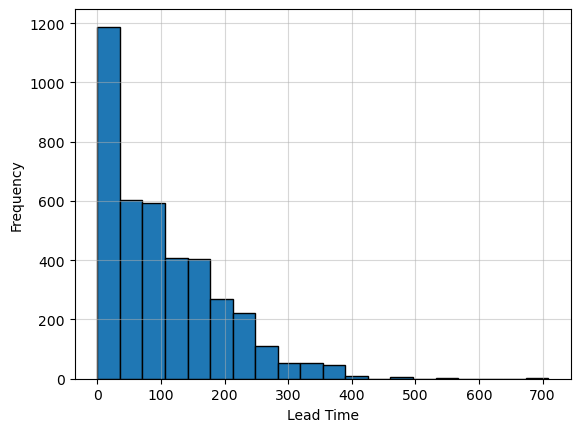

In [104]:
plt.hist(cancellation_final.lead_time,bins=20,edgecolor='black')
plt.grid(alpha=0.5)
plt.xlabel('Lead Time')
plt.ylabel('Frequency')
plt.show()

In [105]:
cancellation_final['lead_time_bucket'] = pd.cut(cancellation_final.lead_time,bins=25)
cancellation_final['lead_time_bucket'] = cancellation_final['lead_time_bucket'].astype('str')
cancellation_final['lead_time_bucket'] = cancellation_final.lead_time_bucket.str.replace('(','')
cancellation_final['lead_time_bucket'] = cancellation_final['lead_time_bucket'].str.replace(']','')

# if lead time bucket in 0-15, 50% cancellation
# if lead time bucket in 15-29, 25% cancellation

In [106]:
cancellation_final

,Booking ID,adr,lead_time,Cancelled,Predicted,Sensitivity,ExpectedRev,lead_time_bucket
0,13292,119.70,385,0,1,0.80,4.79,"368.68, 397.04"
1,38,225.00,22,0,1,0.80,9.00,"-0.709, 28.36"
2,5140,84.00,14,1,1,0.80,3.36,"-0.709, 28.36"
3,21193,237.67,4,0,1,0.80,9.51,"-0.709, 28.36"
4,37751,63.90,61,0,1,0.80,2.56,"56.72, 85.08"
...,...,...,...,...,...,...,...,...
3959,29163,92.00,214,0,1,0.80,3.68,"198.52, 226.88"
3960,6577,116.00,50,1,1,0.80,4.64,"28.36, 56.72"
3961,29381,194.00,66,0,1,0.80,7.76,"56.72, 85.08"
3962,13499,80.00,383,1,1,0.80,3.20,"368.68, 397.04"


In [107]:
cancelled_bookings2 = cancellation_final[cancellation_final['Predicted'] == 1].copy()
cancelled_bookings2.rename(columns={'ExpectedRev':'ExpectedRevenue'},inplace=True)
# cancelled_bookings2['ExpectedRevenue'] = cancelled_bookings2['Cancelled_prob']*cancelled_bookings2['adr']

cancelled_bookings2['ExpectedRevenue2'] = cancelled_bookings2.loc[cancelled_bookings2['lead_time'] < 15,'ExpectedRevenue'] * 0.5
cancelled_bookings2['ExpectedRevenue2'] = cancelled_bookings2.loc[(cancelled_bookings2['lead_time'] >= 15)&(cancelled_bookings2['lead_time'] < 30),'ExpectedRevenue'] * 0.25
cancelled_bookings2['ExpectedRevenue2'] = cancelled_bookings2.loc[(cancelled_bookings2['lead_time'] >= 30)&(cancelled_bookings2['lead_time'] < 45),'ExpectedRevenue'] * 0.10
cancelled_bookings2['ExpectedRevenue2'] = cancelled_bookings2.loc[(cancelled_bookings2['lead_time'] >= 45)&(cancelled_bookings2['lead_time'] < 120),'ExpectedRevenue'] * 0.05
cancelled_bookings2['ExpectedRevenue2'] = cancelled_bookings2.loc[(cancelled_bookings2['lead_time'] >= 120),'ExpectedRevenue'] * 0


cancelled_bookings2.reset_index(drop=True,inplace=True)

cancelled_bookings2['ExpectedRevenue2'] = np.nan

def expected_revenue_func(row):
    if row['lead_time'] >= 0 and row['lead_time'] < 15:
        return row['ExpectedRevenue'] * 0.5
    elif row['lead_time'] >= 15 and row['lead_time'] < 30:
        return row['ExpectedRevenue'] * 0.25
    elif row['lead_time'] >= 30 and row['lead_time'] < 45:
        return row['ExpectedRevenue'] * 0.10
    elif row['lead_time'] >= 45 and row['lead_time'] < 120:
        return row['ExpectedRevenue'] *0.05
    else:
        return row['ExpectedRevenue'] * 0

cancelled_bookings2['ExpectedRevenue2'] = cancelled_bookings2.apply(expected_revenue_func,axis=1)

cancelled_bookings2.rename(columns={'ExpectedRevenue2':'FinalRevenue'},inplace=True)

print('Expected Final Revenue from Cancellations:',int(cancelled_bookings2.FinalRevenue.sum()))

Expected Final Revenue from Cancellations: 2479


The aim of adding a cancellation percentage based on lead time is get a tradeoff between customer satisfaction and additional revenue. Adding a 100% cancellation charge on all lead times would reduce customer satisfaction. But a 0% cancellation charge would lead to loss of revenue opportunities. Therefore, various thresholds have been set based on lead
time to arrive at an optimal decision matrix where there is a balance between customer satisfaction and revenue. 


In [108]:
cancelled_bookings2.drop('lead_time_bucket',axis=1,inplace=True)

In [109]:
cancelled_bookings2

,Booking ID,adr,lead_time,Cancelled,Predicted,Sensitivity,ExpectedRevenue,FinalRevenue
0,13292,119.70,385,0,1,0.80,4.79,0.00
1,38,225.00,22,0,1,0.80,9.00,2.25
2,5140,84.00,14,1,1,0.80,3.36,1.68
3,21193,237.67,4,0,1,0.80,9.51,4.75
4,37751,63.90,61,0,1,0.80,2.56,0.13
...,...,...,...,...,...,...,...,...
3959,29163,92.00,214,0,1,0.80,3.68,0.00
3960,6577,116.00,50,1,1,0.80,4.64,0.23
3961,29381,194.00,66,0,1,0.80,7.76,0.39
3962,13499,80.00,383,1,1,0.80,3.20,0.00


### End